In [22]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Teen_Mental_Health_Dataset.csv')
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
data.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [4]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [10]:
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    print(f"\n{col}:")
    print(data[col].unique())


gender:
<StringArray>
['male', 'female']
Length: 2, dtype: str

platform_usage:
<StringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str

social_interaction_level:
<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


# 4. Data Cleaning

In [13]:
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(0)

In [15]:

data['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [16]:
data['platform_usage'].value_counts()


platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

In [17]:
df = data.copy()

In [21]:
df['platform_usage'] = df['platform_usage'].str.strip().str.title()
df['social_interaction_level'] = df['social_interaction_level'].str.lower()

In [20]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,Tiktok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,Tiktok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


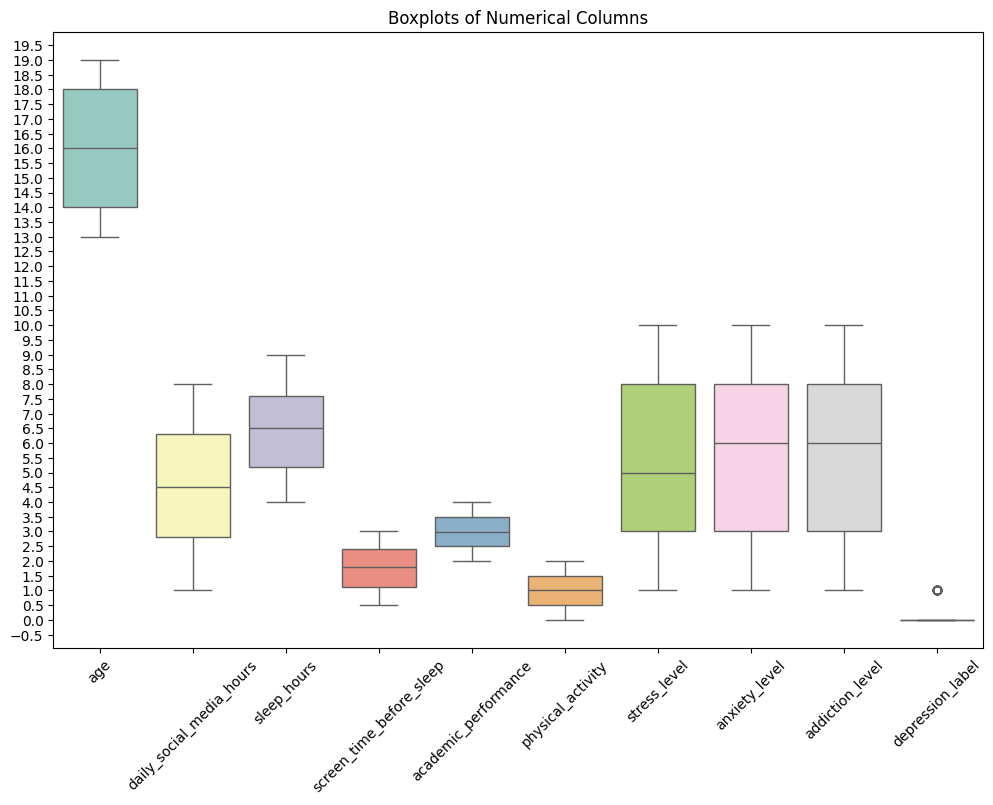

In [35]:
from matplotlib.ticker import MultipleLocator
plt.figure(figsize=(12,8))

ax = sns.boxplot(data=df.select_dtypes(include='number'),palette='Set3')

ax.yaxis.set_major_locator(MultipleLocator(0.5))

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Columns")
plt.show()

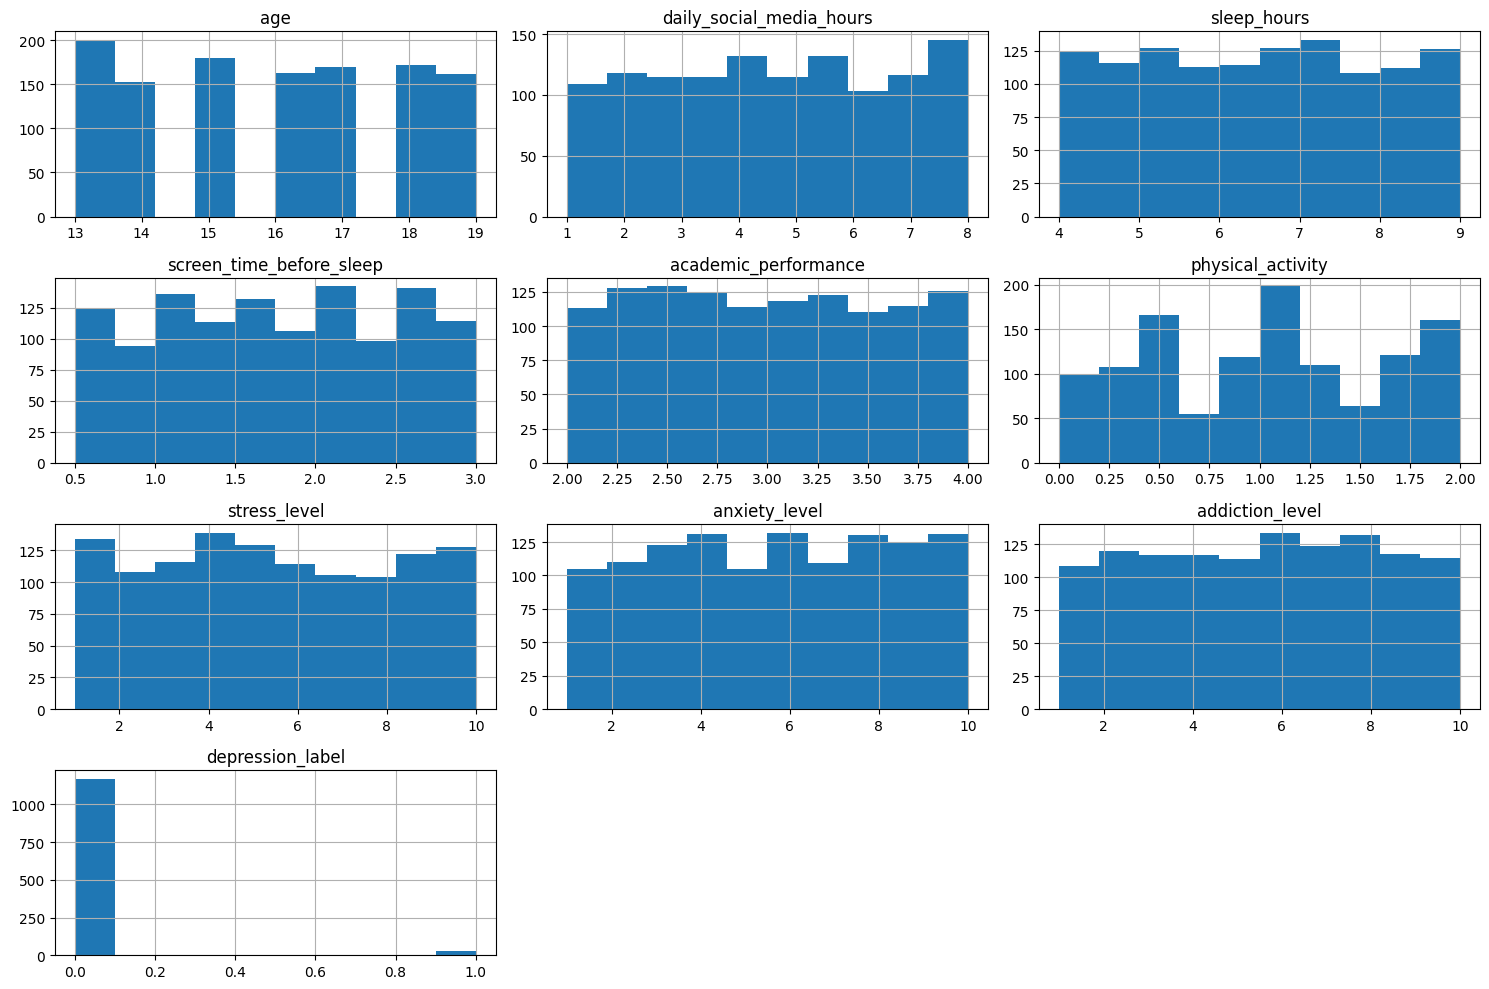

In [39]:
#Univerite analysis " This help me tho analysis the single single feature analysis "

# this help mw to select only number feature
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

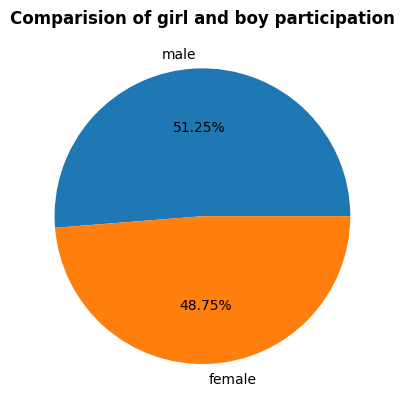

In [ ]:
# comparing the participation of girl and boy with pie chart
plt.Figure(figsize=(18,10))
plt.pie(df['gender'].value_counts(),labels=df['gender'].value_counts().index,autopct='%1.2f%%',)
plt.title("Comparision of girl and boy participation",fontweight = 'bold')
plt.show()


In [47]:
#https://www.kaggle.com/code/mgufrilfirdaus/teen-mental-health-eda
